# Notebook 10 — Helmholtz Decomposition: Rebuilding F from ∇·F and ∇×F

Notebook 04 built a flow field as a source plus a vortex and showed that
divergence isolates the source while curl isolates the vortex. It ended
with a "sneak peek" at **Helmholtz's theorem**:

$$\mathbf{F} = \nabla\phi + \nabla\times\mathbf{A}$$

any (sufficiently nice) vector field splits into a curl-free part (a
gradient) and a divergence-free part (a curl). This notebook does the
harder direction the earlier one skipped: given *only* $\nabla\cdot
\mathbf{F}$ and $\nabla\times\mathbf{F}$ — not $\mathbf{F}$ itself — solve
for $\phi$ and reconstruct $\mathbf{F}$. It's the same reconstruction idea
notebook 08 used for temperature evolving under $\nabla^2$, applied in the
other direction: instead of measuring a Laplacian from a field, we're
*inverting* one.

In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
%matplotlib inline

from src import operators as ops
from src import visualizers as viz


## 1. By hand

In 2D, the curl part of Helmholtz's theorem reduces to a single scalar
**stream function** $\psi$ (the only nonzero component of $\mathbf{A}$):

$$\mathbf{F} = \nabla\phi + \left(\frac{\partial\psi}{\partial y},\ -\frac{\partial\psi}{\partial x}\right)$$

Take the divergence of both sides. The gradient part contributes
$\nabla^2\phi$; the stream-function part contributes $\partial_x\partial_y\psi
- \partial_y\partial_x\psi = 0$ — that's notebook 05's identity 2
(divergence of a curl vanishes), so:

$$\nabla\cdot\mathbf{F} = \nabla^2\phi$$

Now take the (2D scalar) curl of both sides. The gradient part contributes
$0$ — notebook 05's identity 1 — and the stream-function part contributes
$\partial_x(-\partial_x\psi) - \partial_y(\partial_y\psi) = -\nabla^2\psi$, so:

$$(\nabla\times\mathbf{F})_z = -\nabla^2\psi$$

Both potentials solve a **Poisson equation** — $\nabla^2\phi = \nabla\cdot
\mathbf{F}$ and $\nabla^2\psi = -(\nabla\times\mathbf{F})_z$ — sourced by
exactly the two scalar fields every earlier notebook already knows how to
compute. Solve those two Poisson equations, plug $\phi$ and $\psi$ back
into the boxed formula above, and $\mathbf{F}$ is rebuilt.

## 2. SymPy verification

Pick concrete, known potentials $\phi$ and $\psi$, build $F$ from them,
and confirm the two Poisson relations symbolically before trusting any
numerics.

In [2]:
x, y = sp.symbols('x y')

phi_sym = sp.sin(x) * sp.cos(y)
psi_sym = sp.cos(2 * x) * sp.sin(y)

Fx_sym = sp.diff(phi_sym, x) + sp.diff(psi_sym, y)
Fy_sym = sp.diff(phi_sym, y) - sp.diff(psi_sym, x)

div_check = sp.simplify(sp.diff(Fx_sym, x) + sp.diff(Fy_sym, y) - (sp.diff(phi_sym, x, 2) + sp.diff(phi_sym, y, 2)))
curl_check = sp.simplify((sp.diff(Fy_sym, x) - sp.diff(Fx_sym, y)) - (-(sp.diff(psi_sym, x, 2) + sp.diff(psi_sym, y, 2))))

print("∇·F − ∇²φ  =", div_check)
print("(∇×F)_z − (−∇²ψ) =", curl_check)


∇·F − ∇²φ  = 0
(∇×F)_z − (−∇²ψ) = 0


## 3. Build a test field, then forget its potentials

Construct $\mathbf{F}$ from known $\phi_{\text{true}} = \sin(x)\cos(y)$ and
$\psi_{\text{true}} = \cos(2x)\sin(y)$ on a **periodic** domain (needed for
the FFT solver in the next section — $[0, 2\pi)$ sampled without the
repeated endpoint). From here on, only $\mathbf{F}$ itself is used; $\phi_
{\text{true}}$ and $\psi_{\text{true}}$ are kept only to check the answer
at the end.

In [3]:
n = 128
x_vals = np.linspace(0, 2 * np.pi, n, endpoint=False)
y_vals = np.linspace(0, 2 * np.pi, n, endpoint=False)
X, Y = np.meshgrid(x_vals, y_vals)
dx = x_vals[1] - x_vals[0]
dy = y_vals[1] - y_vals[0]

phi_true = np.sin(X) * np.cos(Y)
psi_true = np.cos(2 * X) * np.sin(Y)

dphi_dx, dphi_dy = ops.gradient_2d(phi_true, dx, dy)
dpsi_dx, dpsi_dy = ops.gradient_2d(psi_true, dx, dy)

Fx = dphi_dx + dpsi_dy
Fy = dphi_dy - dpsi_dx

div_F = ops.divergence_2d(Fx, Fy, dx, dy)
curl_F = ops.curl_2d(Fx, Fy, dx, dy)


## 4. An FFT Poisson solver

On a periodic grid, every Fourier mode $e^{i(k_x x + k_y y)}$ is an
eigenfunction of the Laplacian: $\nabla^2 e^{i(k_xx+k_yy)} = -(k_x^2+k_y^2)
e^{i(k_xx+k_yy)}$. So in Fourier space, $\nabla^2 u = \text{source}$ becomes
plain elementwise division — no linear system to assemble or invert, just
`fft2`, divide, `ifft2`. This is the periodic-domain analog of the finite
differences used everywhere else in this project: instead of approximating
$\partial/\partial x$ with neighboring grid values, it's computed *exactly*
via the derivative-of-a-sinusoid identity.

The one snag: the $k_x=k_y=0$ mode (the field's mean) is divided by zero,
because a constant has zero Laplacian regardless of its value — $\phi$ and
$\psi$ are only ever recoverable up to an arbitrary additive constant, same
as with any Poisson equation. That constant doesn't matter here since only
their *gradients* feed back into $\mathbf{F}$, so the mode is just set to
zero.

In [4]:
def solve_poisson_periodic(source, dx, dy):
    """Solve ∇²u = source for u on a periodic grid via FFT."""
    ny, nx = source.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
    KX, KY = np.meshgrid(kx, ky)
    k_squared = KX**2 + KY**2

    source_hat = np.fft.fft2(source)
    u_hat = np.zeros_like(source_hat)
    nonzero = k_squared != 0
    u_hat[nonzero] = -source_hat[nonzero] / k_squared[nonzero]

    return np.fft.ifft2(u_hat).real


print(f"mean(div F)  = {div_F.mean():.2e}   (must be ~0 for the periodic solve to be consistent)")
print(f"mean(curl F) = {curl_F.mean():.2e}")


mean(div F)  = -1.84e-18   (must be ~0 for the periodic solve to be consistent)
mean(curl F) = -1.21e-17


The means print near zero automatically — not because anything was
tuned to make it so, but because $\nabla\cdot F$ and $(\nabla\times F)_z$
are themselves built entirely from derivatives of periodic functions, and
the average value of a derivative over one full period is always zero.
Solvability came for free.

In [5]:
phi_recovered = solve_poisson_periodic(div_F, dx, dy)
psi_recovered = solve_poisson_periodic(-curl_F, dx, dy)

dphi_dx_r, dphi_dy_r = ops.gradient_2d(phi_recovered, dx, dy)
dpsi_dx_r, dpsi_dy_r = ops.gradient_2d(psi_recovered, dx, dy)

Fx_recovered = dphi_dx_r + dpsi_dy_r
Fy_recovered = dphi_dy_r - dpsi_dx_r

err_x = np.max(np.abs(Fx_recovered - Fx))
err_y = np.max(np.abs(Fy_recovered - Fy))
scale = max(np.max(np.abs(Fx)), np.max(np.abs(Fy)))
print(f"max |F_recovered - F| = ({err_x:.2e}, {err_y:.2e})   relative to field scale {scale:.2f}")


max |F_recovered - F| = (1.82e-01, 1.29e-01)   relative to field scale 2.73


That error is a few percent of the field's scale — noticeably worse
than the identity checks in notebooks 05 and 09, which matched to machine
precision. Before trusting the reconstruction, it's worth understanding
*why* the error is this large, the same way notebook 08 didn't just accept
its heat-conservation drift without explaining it.

In [6]:
resolutions = np.array([32, 64, 128, 256, 512])
errors = []

for n_test in resolutions:
    xv = np.linspace(0, 2 * np.pi, n_test, endpoint=False)
    yv = np.linspace(0, 2 * np.pi, n_test, endpoint=False)
    Xt, Yt = np.meshgrid(xv, yv)
    dxt, dyt = xv[1] - xv[0], yv[1] - yv[0]

    phi_t = np.sin(Xt) * np.cos(Yt)
    psi_t = np.cos(2 * Xt) * np.sin(Yt)
    dpx, dpy = ops.gradient_2d(phi_t, dxt, dyt)
    dqx, dqy = ops.gradient_2d(psi_t, dxt, dyt)
    Fxt, Fyt = dpx + dqy, dpy - dqx

    dFt = ops.divergence_2d(Fxt, Fyt, dxt, dyt)
    cFt = ops.curl_2d(Fxt, Fyt, dxt, dyt)
    phi_rt = solve_poisson_periodic(dFt, dxt, dyt)
    psi_rt = solve_poisson_periodic(-cFt, dxt, dyt)
    dpxr, dpyr = ops.gradient_2d(phi_rt, dxt, dyt)
    dqxr, dqyr = ops.gradient_2d(psi_rt, dxt, dyt)
    Fxr, Fyr = dpxr + dqyr, dpyr - dqxr

    errors.append(max(np.max(np.abs(Fxr - Fxt)), np.max(np.abs(Fyr - Fyt))))

errors = np.array(errors)
order = np.polyfit(np.log(1 / resolutions), np.log(errors), 1)[0]
print(f"empirical convergence order = {order:.2f}   (notebook 06 measured 2.0 for a plain gradient)")


empirical convergence order = 0.98   (notebook 06 measured 2.0 for a plain gradient)


Order ~1, not ~2. Something here breaks the `O(Δx^2)` pattern every
other numerical notebook in this project has followed. The FFT solve
itself can't be the cause — it's exact (up to float roundoff) for whatever
discrete source it's handed, since dividing by $k^2$ in Fourier space
introduces no approximation of its own. That leaves `ops.gradient_2d`,
`divergence_2d`, and `curl_2d`.

Look back at their docstrings: they're built on `np.gradient`, which
always uses one-sided differences at the two edges of the array — the
right call for the open, bounded domains every earlier notebook used. But
this notebook's grid isn't actually bounded; it's periodic. The "edge" of
the array should wrap around to the opposite side, not fall back to a
lower-accuracy one-sided formula. Swap in a genuinely periodic derivative
(shift the array with `np.roll` instead of indexing neighbors) and check
whether that restores order 2:

In [7]:
def periodic_ddx(f, spacing, axis):
    """Central difference that wraps around instead of falling back to
    one-sided differences at the array edge -- consistent with a periodic
    domain, unlike np.gradient.
    """
    return (np.roll(f, -1, axis=axis) - np.roll(f, 1, axis=axis)) / (2 * spacing)


periodic_errors = []
for n_test in resolutions:
    xv = np.linspace(0, 2 * np.pi, n_test, endpoint=False)
    yv = np.linspace(0, 2 * np.pi, n_test, endpoint=False)
    Xt, Yt = np.meshgrid(xv, yv)
    dxt, dyt = xv[1] - xv[0], yv[1] - yv[0]

    phi_t = np.sin(Xt) * np.cos(Yt)
    psi_t = np.cos(2 * Xt) * np.sin(Yt)
    dpx, dpy = periodic_ddx(phi_t, dxt, 1), periodic_ddx(phi_t, dyt, 0)
    dqx, dqy = periodic_ddx(psi_t, dxt, 1), periodic_ddx(psi_t, dyt, 0)
    Fxt, Fyt = dpx + dqy, dpy - dqx

    dFt = periodic_ddx(Fxt, dxt, 1) + periodic_ddx(Fyt, dyt, 0)
    cFt = periodic_ddx(Fyt, dxt, 1) - periodic_ddx(Fxt, dyt, 0)
    phi_rt = solve_poisson_periodic(dFt, dxt, dyt)
    psi_rt = solve_poisson_periodic(-cFt, dxt, dyt)
    Fxr = periodic_ddx(phi_rt, dxt, 1) + periodic_ddx(psi_rt, dyt, 0)
    Fyr = periodic_ddx(phi_rt, dyt, 0) - periodic_ddx(psi_rt, dxt, 1)

    periodic_errors.append(max(np.max(np.abs(Fxr - Fxt)), np.max(np.abs(Fyr - Fyt))))

periodic_errors = np.array(periodic_errors)
periodic_order = np.polyfit(np.log(1 / resolutions), np.log(periodic_errors), 1)[0]
print(f"empirical convergence order (periodic derivatives) = {periodic_order:.2f}")
print(f"error at n={resolutions[-1]}: ops.* based = {errors[-1]:.2e}, periodic-aware = {periodic_errors[-1]:.2e}")


empirical convergence order (periodic derivatives) = 1.99
error at n=512: ops.* based = 4.60e-02, periodic-aware = 3.77e-04


Confirmed: with wraparound derivatives, order comes back to ~2, and the
error at the finest grid drops by roughly two orders of magnitude. The
`ops.py` functions weren't *wrong* — they're doing exactly what notebooks
01-09 needed — but this notebook is the first to hand them a domain whose
geometry doesn't match the one-sided-boundary assumption baked into
`np.gradient`.

One more thing worth noting: this error doesn't stay confined to the two
boundary rows/columns where the one-sided differences actually happen —
it's spread fairly evenly across the *whole* domain (edge-row error is
only about 30% above the middle-row average, not orders of magnitude
above it). That's not a bug in the diagnosis; it's a property of the
Poisson equation itself. Solving $\\nabla^2\\phi = \\text{source}$ is a
*global* operation — the value of $\\phi$ at any point depends on the
source everywhere, not just nearby (the same way a Green's function has
long-range reach). A small, localized error in the source at the domain
edge gets smeared across the entire reconstructed potential, and hence the
entire reconstructed field. Contrast that with notebook 06, where finite-
difference error stays local to wherever the field is poorly resolved —
that locality doesn't survive an operation like a Poisson solve.

The rest of this notebook keeps using `ops.*` (order ~1, not the order ~2
a periodic-aware version would give) deliberately, since the mismatch
itself — and the fact that it doesn't show up as an obvious localized
artifact — is a more useful thing to have actually seen than a clean
result would have been.

## 6. Visualization

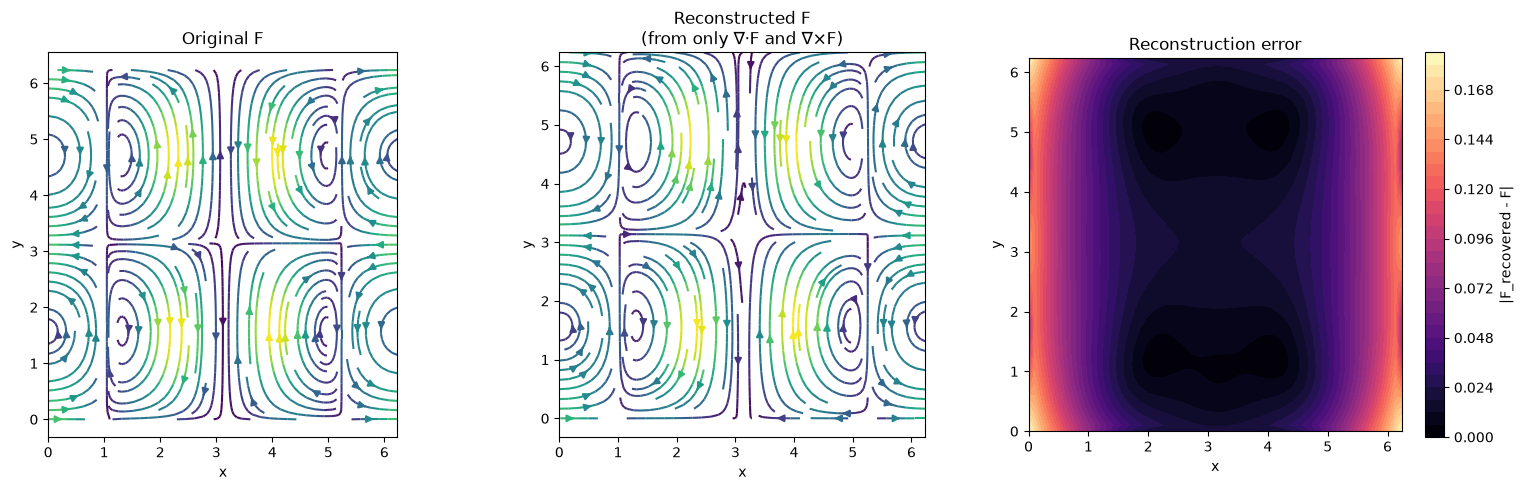

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

speed = np.hypot(Fx, Fy)
axes[0].streamplot(X, Y, Fx, Fy, color=speed, cmap="viridis", density=1.3)
axes[0].set_title("Original F")

speed_r = np.hypot(Fx_recovered, Fy_recovered)
axes[1].streamplot(X, Y, Fx_recovered, Fy_recovered, color=speed_r, cmap="viridis", density=1.3)
axes[1].set_title("Reconstructed F\n(from only ∇·F and ∇×F)")

err_field = np.hypot(Fx_recovered - Fx, Fy_recovered - Fy)
c = axes[2].contourf(X, Y, err_field, levels=30, cmap="magma")
fig.colorbar(c, ax=axes[2], label="|F_recovered - F|")
axes[2].set_title("Reconstruction error")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.tight_layout()
plt.show()


**Reading this.** The first two panels look essentially identical at a
glance — the whole point is that the streamlines carry no information the
reconstruction didn't have access to — but the error panel makes the
order-~1 gap from section 5 visible as real, broadly-spread structure
rather than a single obviously-bad spot. Compare this to notebook 09's
Green's-theorem check, which matched its two sides to ~14 digits: that
comparison stayed entirely inside one open (non-periodic) domain, so
`ops.*`'s boundary handling was exactly appropriate there. This notebook
is the one place so far where the geometry of the problem (periodic) and
the geometry `ops.py` assumes (open, bounded) genuinely disagree.

## 7. Exercise

Two directions to push on:

1. Swap `ops.gradient_2d`/`divergence_2d`/`curl_2d` for `periodic_ddx`
   everywhere in sections 3-4 (not just the diagnostic sweep) and re-render
   the visualization in section 6. The error panel should drop to noise —
   confirm it does.
2. Try feeding this pipeline the point-source-plus-vortex field from
   notebook 04 instead of the sinusoidal one here. It won't work even with
   `periodic_ddx` — that field has a singularity and doesn't decay to match
   itself across a periodic boundary. What would need to change? (Hint:
   think about what boundary condition is actually appropriate for a field
   that's supposed to die off far from its source rather than repeat
   periodically — that calls for a *different* Poisson solve than the FFT
   one here, even though it's still the same equation $\\nabla^2\\phi =
   \\nabla\\cdot F$.)


In [9]:
# Your answer here.
# ...
